# sprint 1. eda: exploracao e merge dos dados

projeto: infant dysbiosis predictor  
dados utilizados: supplementary data 2 (metadados clinicos + microbioma), data 4 (amr e vf), data 6 (desfechos 2 anos)  

objetivo deste notebook: entender a estrutura dos dados, identificar missings, distribuicoes das variaveis clinicas e preparar o dataset para os modelos nas proximas sprints.

## 0. imports e configuracoes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%pip install openpyxl

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 20)

/Users/isa/.zshenv:.:1: no such file or directory: /Users/isa/.cargo/env
Note: you may need to restart the kernel to use updated packages.


## 1. carregamento dos dados

carregamos os tres arquivos separadamente antes de fazer o merge. isso permite inspecionar cada um de forma independente e entender o que cada um contem.

In [3]:
df2 = pd.read_excel('../data/Supplementary Data 2.xlsx')
df4 = pd.read_excel('../data/Supplementary Data 4.xlsx')
df6 = pd.read_excel('../data/Supplementary Data 6.xlsx')

print(f'data 2: {df2.shape[0]} amostras, {df2.shape[1]} colunas')
print(f'data 4: {df4.shape[0]} amostras, {df4.shape[1]} colunas')
print(f'data 6: {df6.shape[0]} amostras, {df6.shape[1]} colunas')

data 2: 412 amostras, 564 colunas
data 4: 412 amostras, 3 colunas
data 6: 210 amostras, 7 colunas


## 2. inspecao do data 2: metadados clinicos e microbioma

o data 2 e o arquivo principal.

ele contem 412 amostras e 564 colunas. 

as primeiras colunas sao variaveis clinicas (tipo de parto, dieta, sexo, etc.) e as restantes sao abundancias relativas de 550 especies bacterianas.

separamos as colunas clinicas das colunas de microbioma para facilitar a analise.

In [4]:
clinical_cols = [
    'sample_id', 'dmm_clusters_taxa', 'birth_mode', 'feeding_mode',
    'baby_antibiotics', 'mother_antibiotics', 'baby_sex',
    'baby_ethnicity', 'baby_race', 'pH',
    'Normed Age at Collection (days)'
]

df2_clinical = df2[clinical_cols].copy()
df2_clinical.head()

,sample_id,dmm_clusters_taxa,birth_mode,feeding_mode,baby_antibiotics,mother_antibiotics,baby_sex,baby_ethnicity,baby_race,pH,Normed Age at Collection (days)
0,sample_1,C2,Vaginal,Mixed,No,No,Female,Not Hispanic or Latino,White,7.10,46
1,sample_2,C3,Vaginal,Breast,No,No,Female,Not Hispanic or Latino,White,6.28,53
2,sample_3,C2,Vaginal,Breast,No,No,Male,Not Hispanic or Latino,White,NaN,81
3,sample_4,C3,Vaginal,Mixed,No,No,Female,Not Hispanic or Latino,White,6.60,71
4,sample_5,C1,Vaginal,Breast,No,No,Male,Not Hispanic or Latino,White,5.27,63


In [5]:
# colunas de microbioma: todas as numericas que nao sao clinicas
bacteria_cols = [
    c for c in df2.columns
    if c not in clinical_cols and df2[c].dtype in ['float64', 'float32']
]
print(f'numero de especies bacterianas: {len(bacteria_cols)}')
print(f'exemplos: {bacteria_cols[:5]}')

numero de especies bacterianas: 550
exemplos: ['Acetatifactor sp900066565', 'Achromobacter marplatensis', 'Acidaminococcus intestini', 'Acinetobacter towneri', 'Actinobaculum massiliense']


## 3. analise de missings

onde ta os valores ausentes?

a variavel pH tem muitos missings (206 de 412) e por isso sera tratada com cuidado.

In [6]:
missing = df2_clinical.isnull().sum()
missing_pct = (missing / len(df2_clinical) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df[missing_df['missing'] > 0]

,missing,pct
pH,206,50.0


In [7]:
# resumo de missings nas variaveis clinicas
missing = df2_clinical.isnull().sum()
missing_pct = (missing / len(df2_clinical) * 100).round(1)

missing_df = pd.DataFrame({
    'variavel': missing.index,
    'missing': missing.values,
    'pct': missing_pct.values
}).query('missing > 0')

print('variaveis com valores ausentes:')
print(missing_df.to_string(index=False))
print('\nnota: pH sera excluido das features por ter 50% de missings')

variaveis com valores ausentes:
variavel  missing  pct
      pH      206 50.0

nota: pH sera excluido das features por ter 50% de missings


## 4. distribuicao da variavel alvo: clusters dmm

o cluster dmm eh a variavel alvo do modelo 2. 

ele foi definido pelo paper original usando dirichlet multinomial mixture clustering sobre os dados de microbioma. 


nosso objetivo e prever esse cluster usando apenas variaveis clinicas simples.

os tres clusters representam estados distintos do microbioma intestinal: c1 eh saudavel (rico em bifidobacterium), c2 eh intermediario e c3 eh de alto risco (pobre em bifidobacterium, rico em firmicutes e proteobacteria)

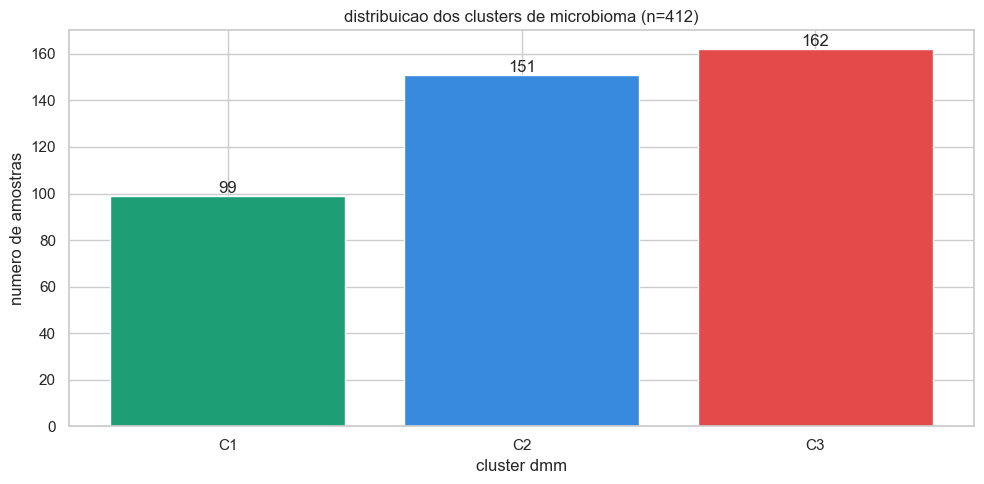

dmm_clusters_taxa
C1     99
C2    151
C3    162
Name: count, dtype: int64

porcentagens:
dmm_clusters_taxa
C1    24.0
C2    36.7
C3    39.3
Name: count, dtype: float64


In [13]:
cluster_counts = df2_clinical['dmm_clusters_taxa'].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(cluster_counts.index, cluster_counts.values,
              color=['#1D9E75', '#378ADD', '#E24B4A'])
ax.bar_label(bars, fmt='%d')
ax.set_xlabel('cluster dmm')
ax.set_ylabel('numero de amostras')
ax.set_title('distribuicao dos clusters de microbioma (n=412)')
plt.tight_layout()
plt.show()

print(cluster_counts)
print(f'\nporcentagens:')
print((cluster_counts / cluster_counts.sum() * 100).round(1))

## 5. distribuicao das variaveis clinicas

aqui vamos explorar cada variavel clinica que sera usada como feature nos dois modelos. 

para cada uma, verificamos a distribuicao geral e a relacao com o cluster dmm.

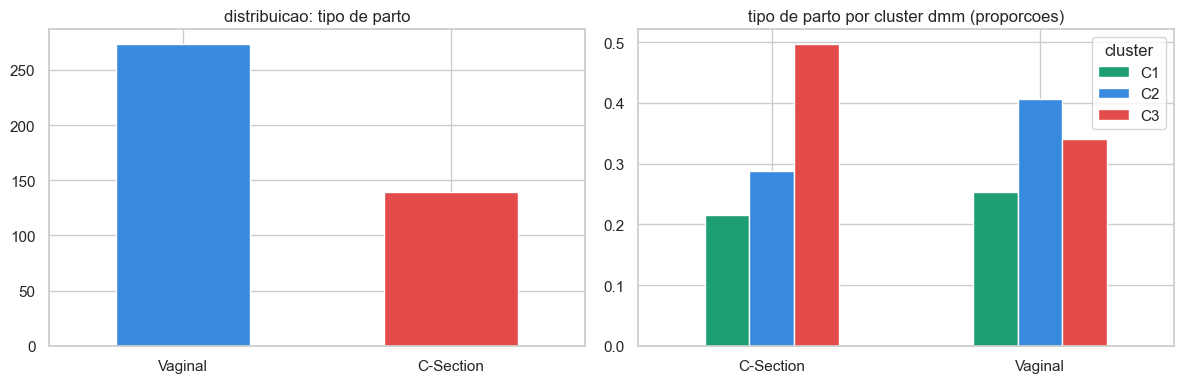

In [14]:
# tipo de parto
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df2_clinical['birth_mode'].value_counts().plot(kind='bar', ax=axes[0], color=['#378ADD', '#E24B4A'])
axes[0].set_title('distribuicao: tipo de parto')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(df2_clinical['birth_mode'], df2_clinical['dmm_clusters_taxa'],
            normalize='index').plot(kind='bar', ax=axes[1],
            color=['#1D9E75', '#378ADD', '#E24B4A'])
axes[1].set_title('tipo de parto por cluster dmm (proporcoes)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='cluster')

plt.tight_layout()
plt.show()

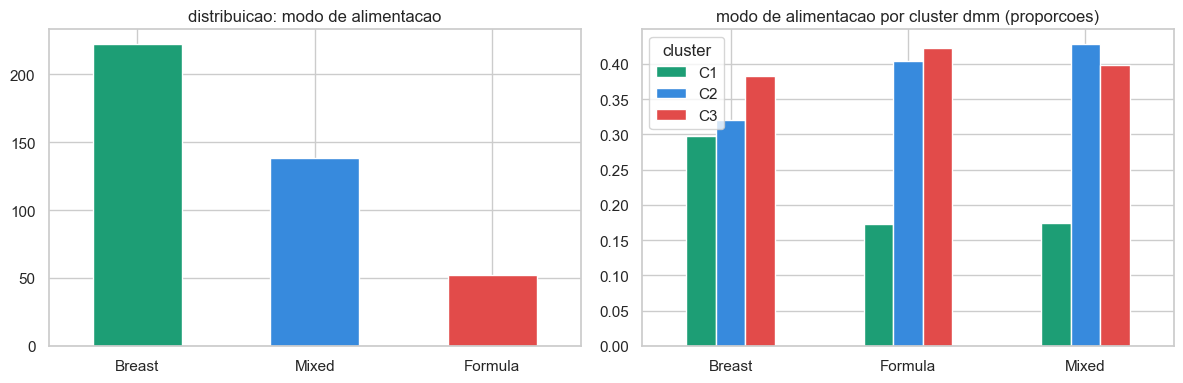

In [15]:
# modo de alimentacao
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df2_clinical['feeding_mode'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#1D9E75', '#378ADD', '#E24B4A'])
axes[0].set_title('distribuicao: modo de alimentacao')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(df2_clinical['feeding_mode'], df2_clinical['dmm_clusters_taxa'],
            normalize='index').plot(kind='bar', ax=axes[1],
            color=['#1D9E75', '#378ADD', '#E24B4A'])
axes[1].set_title('modo de alimentacao por cluster dmm (proporcoes)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='cluster')

plt.tight_layout()
plt.show()

In [16]:
# antibiotico materno
# nota: baby_antibiotics tem valor 'No' para todas as 412 amostras, entao nao sera usada como feature
print('baby_antibiotics (todos os valores):')
print(df2_clinical['baby_antibiotics'].value_counts())
print('\ncomo todos os bebes sao No, essa variavel nao tem poder preditivo e sera removida')

print('\nmother_antibiotics:')
print(df2_clinical['mother_antibiotics'].value_counts())

baby_antibiotics (todos os valores):
baby_antibiotics
No    412
Name: count, dtype: int64

como todos os bebes sao No, essa variavel nao tem poder preditivo e sera removida

mother_antibiotics:
mother_antibiotics
No     402
Yes     10
Name: count, dtype: int64


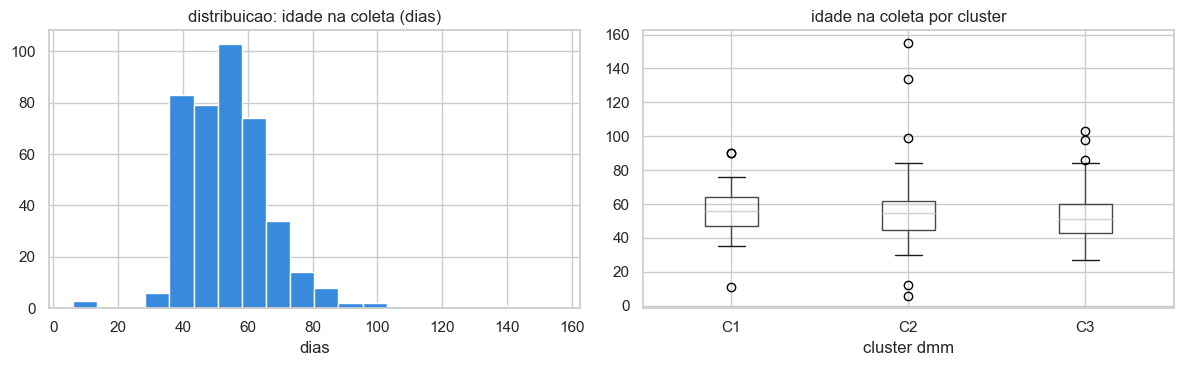

In [17]:
# idade na coleta
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df2_clinical['Normed Age at Collection (days)'], bins=20,
             color='#378ADD', edgecolor='white')
axes[0].set_title('distribuicao: idade na coleta (dias)')
axes[0].set_xlabel('dias')

df2_clinical.boxplot(column='Normed Age at Collection (days)',
                     by='dmm_clusters_taxa', ax=axes[1])
axes[1].set_title('idade na coleta por cluster')
axes[1].set_xlabel('cluster dmm')
plt.suptitle('')

plt.tight_layout()
plt.show()

pH disponivel em 206 de 412 amostras (50%)


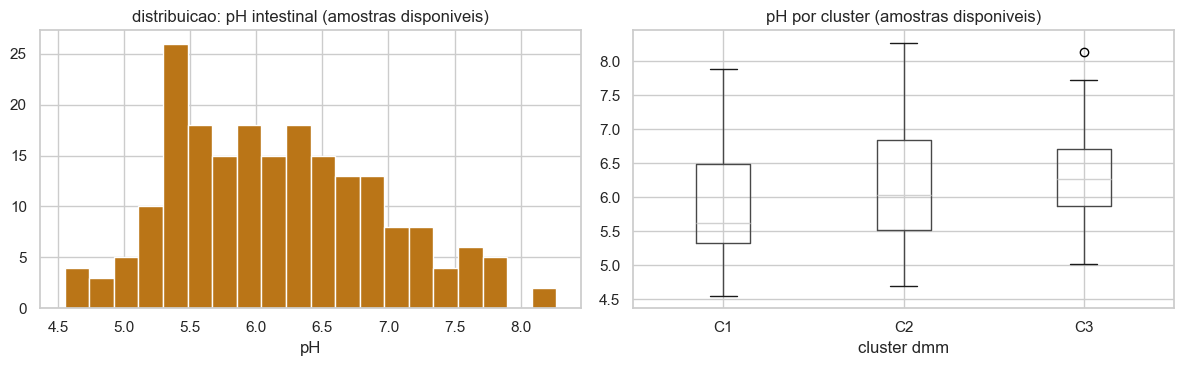

In [18]:
# pH intestinal: 206 missings de 412. plotamos apenas os disponiveis
ph_available = df2_clinical['pH'].dropna()
print(f'pH disponivel em {len(ph_available)} de {len(df2_clinical)} amostras ({len(ph_available)/len(df2_clinical)*100:.0f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ph_available, bins=20, color='#BA7517', edgecolor='white')
axes[0].set_title('distribuicao: pH intestinal (amostras disponiveis)')
axes[0].set_xlabel('pH')

df2_clinical.dropna(subset=['pH']).boxplot(
    column='pH', by='dmm_clusters_taxa', ax=axes[1])
axes[1].set_title('pH por cluster (amostras disponiveis)')
axes[1].set_xlabel('cluster dmm')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 6. inspecao do data 4: amr e vf

o data 4 contem duas features numericas por amostra: a abundancia de genes de resistencia antimicrobiana (amr) e de fatores de virulencia (vf). 

essas variaveis capturam o perfil de risco genetico do microbioma e serao incluidas como features adicionais nos dois modelos, ja que sao mais informativas do que apenas as variaveis clinicas demograficas.

In [19]:
df4.describe().round(6)

,amr_gene_sum_abundance,vf_sum_abundance
count,412.000000,412.000000
mean,0.003218,0.003292
std,0.001149,0.004505
min,0.001205,0.000000
25%,0.002280,0.000511
50%,0.003095,0.001447
75%,0.003988,0.004351
max,0.007359,0.032425


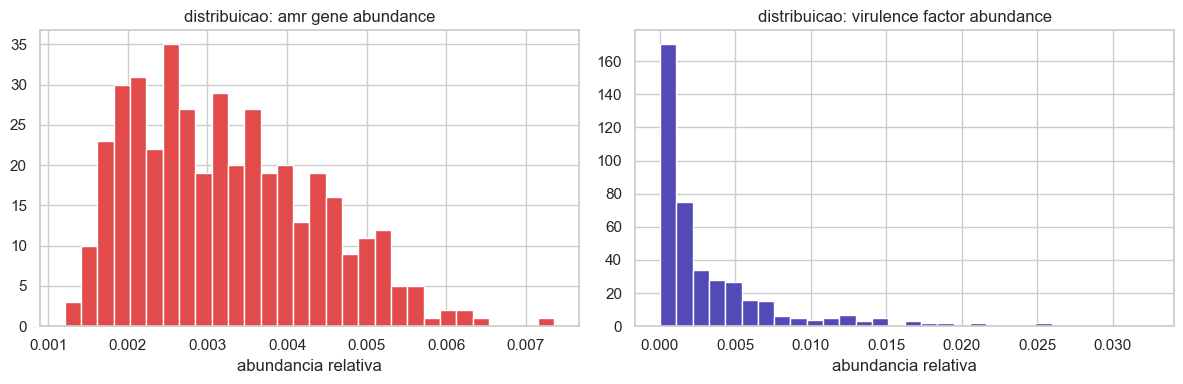

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df4['amr_gene_sum_abundance'], bins=30, color='#E24B4A', edgecolor='white')
axes[0].set_title('distribuicao: amr gene abundance')
axes[0].set_xlabel('abundancia relativa')

axes[1].hist(df4['vf_sum_abundance'], bins=30, color='#534AB7', edgecolor='white')
axes[1].set_title('distribuicao: virulence factor abundance')
axes[1].set_xlabel('abundancia relativa')

plt.tight_layout()
plt.show()

## 7. inspecao do data 6: desfechos aos 2 anos

o data 6 contem o follow-up de 210 familias (de 412 iniciais). 

a variavel alvo do modelo 1 e adverse_outcomes: 1 indica que a crianca foi diagnosticada com pelo menos uma condicao atopica (alergia, asma ou eczema) ate os 2 anos.

nota: a coluna de eczema tem 4 entradas com valor 0 (provavelmente missing codificado de forma diferente). 

isso sera tratado no pre-processamento.

In [21]:
df6.head(10)

,sample_id,dmm_clusters_taxa_paper,adverse_outcomes,antibiotics_first_2_years,allergies,Has_your_child_been_diagnosed_with_asthma,Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis
0,sample_412,2,1,1,No,No,Yes
1,sample_404,3,0,0,No,No,No
2,sample_411,2,0,0,No,No,0
3,sample_384,3,0,0,No,No,No
4,sample_409,3,1,1,Yes,No,No
5,sample_410,3,0,1,No,No,No
6,sample_344,3,0,0,No,No,No
7,sample_362,3,1,0,No,No,Yes
8,sample_399,3,0,0,No,No,No
9,sample_403,3,0,1,No,No,No


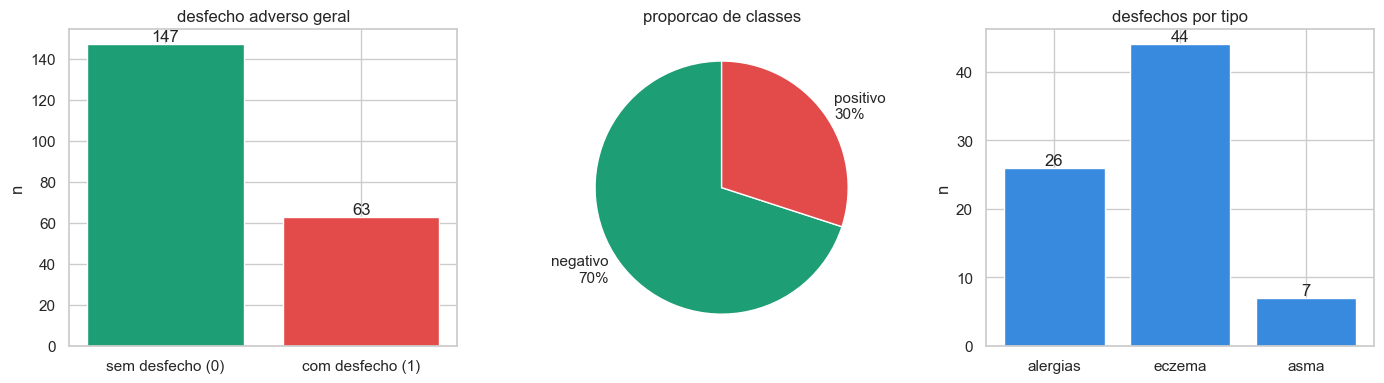

total com follow-up: 210
positivos: 63 (30.0%)
negativos: 147 (70.0%)

nota: o desbalanceamento de classes (70/30) justifica o uso de recall como metrica principal


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# desfecho adverso geral
counts = df6['adverse_outcomes'].value_counts()
axes[0].bar(['sem desfecho (0)', 'com desfecho (1)'], counts.values,
            color=['#1D9E75', '#E24B4A'])
axes[0].bar_label(axes[0].containers[0], fmt='%d')
axes[0].set_title('desfecho adverso geral')
axes[0].set_ylabel('n')

# desbalanceamento em porcentagem
pct = counts / counts.sum() * 100
axes[1].pie(pct.values, labels=[f'negativo\n{pct[0]:.0f}%', f'positivo\n{pct[1]:.0f}%'],
            colors=['#1D9E75', '#E24B4A'], startangle=90)
axes[1].set_title('proporcao de classes')

# desfechos por tipo
tipo_counts = {
    'alergias': (df6['allergies'] == 'Yes').sum(),
    'eczema': (df6['Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis'] == 'Yes').sum(),
    'asma': (df6['Has_your_child_been_diagnosed_with_asthma'] == 'Yes').sum()
}
axes[2].bar(tipo_counts.keys(), tipo_counts.values(), color='#378ADD')
axes[2].bar_label(axes[2].containers[0], fmt='%d')
axes[2].set_title('desfechos por tipo')
axes[2].set_ylabel('n')

plt.tight_layout()
plt.show()

print(f'total com follow-up: {len(df6)}')
print(f'positivos: {counts[1]} ({pct[1]:.1f}%)')
print(f'negativos: {counts[0]} ({pct[0]:.1f}%)')
print('\nnota: o desbalanceamento de classes (70/30) justifica o uso de recall como metrica principal')

In [23]:
# uso de antibioticos nos 2 primeiros anos (covariate do modelo 1)
ab2 = df6['antibiotics_first_2_years'].value_counts()
print('uso de antibioticos nos primeiros 2 anos:')
print(ab2)
print(f'\n{ab2[1]/len(df6)*100:.1f}% das criancas usaram antibioticos ate os 2 anos')
print('essa variavel sera incluida como covariate no modelo 1, seguindo a metodologia do paper original')

uso de antibioticos nos primeiros 2 anos:
antibiotics_first_2_years
1    113
0     97
Name: count, dtype: int64

53.8% das criancas usaram antibioticos ate os 2 anos
essa variavel sera incluida como covariate no modelo 1, seguindo a metodologia do paper original


## 8. merge dos tres datasets

fazemos dois merges distintos para os dois modelos.

modelo 2 (classificacao de cluster): usa data 2 + data 4, n=412  
modelo 1 (predicao de desfecho): usa data 2 + data 4 + data 6, n=210 (subconjunto com follow-up)

In [24]:
# dataset para o modelo 2: todos os 412 bebes
df_model2 = df2_clinical.merge(df4, on='sample_id', how='inner')
print(f'dataset modelo 2: {df_model2.shape}')
print(f'missings: {df_model2.isnull().sum()[df_model2.isnull().sum() > 0].to_dict()}')

dataset modelo 2: (412, 13)
missings: {'pH': 206}


In [25]:
# dataset para o modelo 1: apenas os 210 com follow-up
df_model1 = df_model2.merge(df6, on='sample_id', how='inner')
print(f'dataset modelo 1: {df_model1.shape}')
print(f'missings: {df_model1.isnull().sum()[df_model1.isnull().sum() > 0].to_dict()}')

dataset modelo 1: (210, 19)
missings: {'pH': 100}


## 9. analise do cluster vs desfecho adverso

essa analise conecta os dois modelos: verificamos se o cluster do microbioma (alvo do modelo 2) esta associado ao desfecho adverso aos 2 anos (alvo do modelo 1). 


o paper reporta isso via risco relativo; aqui faremos a visualizacao direta.

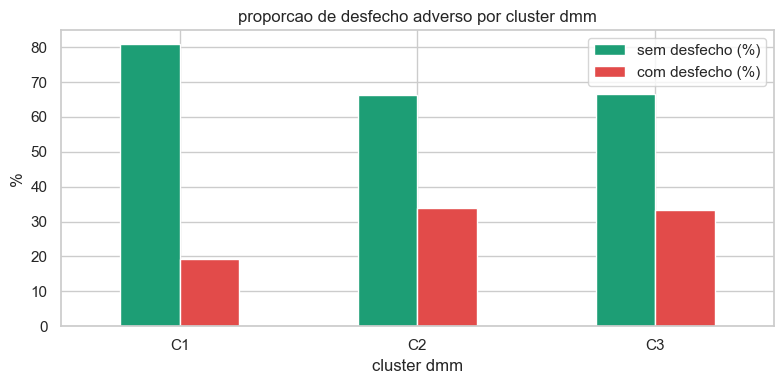

                   sem desfecho (%)  com desfecho (%)
dmm_clusters_taxa                                    
C1                             80.8              19.2
C2                             66.2              33.8
C3                             66.7              33.3


In [26]:
ct = pd.crosstab(df_model1['dmm_clusters_taxa'], df_model1['adverse_outcomes'],
                 normalize='index') * 100
ct.columns = ['sem desfecho (%)', 'com desfecho (%)']

fig, ax = plt.subplots(figsize=(8, 4))
ct.plot(kind='bar', ax=ax, color=['#1D9E75', '#E24B4A'])
ax.set_title('proporcao de desfecho adverso por cluster dmm')
ax.set_xlabel('cluster dmm')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(ct.round(1))

## 10. selecao final de features e exportacao

definimos as features que entram em cada modelo e exportamos os datasets limpos para uso nas proximas sprints.

features excluidas: baby_antibiotics (valor unico para todos), pH (50% missing), baby_birthday, sample_storage (variaveis de controle sem poder preditivo clinico).

In [ ]:
features = [
    'birth_mode',
    'feeding_mode',
    'mother_antibiotics',
    'baby_sex',
    'baby_ethnicity',
    'Normed Age at Collection (days)',
    'amr_gene_sum_abundance',
    'vf_sum_abundance'
]

# modelo 2: cluster como target
df_m2_clean = df_model2[['sample_id'] + features + ['dmm_clusters_taxa']].copy()
df_m2_clean.to_csv('data/model2_dataset.csv', index=False)
print(f'modelo 2 exportado: {df_m2_clean.shape}')
print(f'features: {features}')
print(f'target: dmm_clusters_taxa (C1/C2/C3)')

print()

# modelo 1: desfecho adverso como target
df_m1_clean = df_model1[['sample_id'] + features + ['antibiotics_first_2_years', 'adverse_outcomes']].copy()
df_m1_clean.to_csv('data/model1_dataset.csv', index=False)
print(f'modelo 1 exportado: {df_m1_clean.shape}')
print(f'features: {features + ["antibiotics_first_2_years"]}')
print(f'target: adverse_outcomes (0/1)')

In [ ]:
# resumo final
print('=== resumo da eda ===')
print(f'dataset completo (modelo 2): {df_m2_clean.shape[0]} amostras, {len(features)} features, target: cluster c1/c2/c3')
print(f'dataset follow-up (modelo 1): {df_m1_clean.shape[0]} amostras, {len(features)+1} features, target: desfecho adverso 0/1')
print(f'desbalanceamento modelo 1: {(df_m1_clean["adverse_outcomes"]==1).sum()} positivos de {len(df_m1_clean)} ({(df_m1_clean["adverse_outcomes"]==1).mean()*100:.1f}%)')
print(f'missings nos datasets finais: {df_m2_clean.isnull().sum().sum()} (modelo 2), {df_m1_clean.isnull().sum().sum()} (modelo 1)')
print('\nproxima sprint: pre-processamento completo (encoding, scaling) e treinamento do modelo 2')